## 授權與來源（License & Attribution）

本課程自編／改編的程式與文字：Copyright 2026 leonjyentub；Apache License 2.0（`../LICENSE`）。
教學概念與來源參照：Aurélien Géron, `ageron/handson-mlp` Appendix A 自動微分，上游 Apache-2.0，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`。
本檔改編／創作說明：依原書概念另編可於 CPU 執行的小型機制實驗、示範圖表與中文教學解釋；不等同於完整上游實驗，亦不表示每段程式均直接複製上游。
詳細對照：`../SOURCES.md`；授權及署名：`../THIRD_PARTY_NOTICES.md`。
其他第三方資料、圖片及模型權利按各自來源處理，不包含在本課程程式授權中。

# 24｜附錄A_自動微分與計算圖

以中央差分檢查解析梯度，並觀察步長過大或過小的誤差。

對應 `slides/24_附錄A_自動微分與計算圖.md`；從第一格依序執行即可重現投影片中的表格與圖。

## 來源與改編界線

- Aurélien Géron，`handson-mlp/Appendix_A_autodiff.ipynb`，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`，參考 Cells 6、17–23（數值微分與 toy computation graph）。

- `MachineLearning2025/06_ANN_from_Scratch_MNIST.py`，固定 commit `3da2cb56b9efd17d7cd34602589f392554b40603`。
- 本 Notebook 為課堂短實驗：保留核心張量、演算法或評估流程，改用 NumPy／scikit-learn 與小型資料，讓 CPU 能快速重跑。
- 圖表與數值是本檔實際執行結果，不代表原書完整模型成效。原始程式授權與歸屬見 `../NOTICE.md`。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import SEED, setup, savefig, report
setup()
rng = np.random.default_rng(SEED)

## 課堂小實驗

In [2]:
def f(x, y): return x*x*y + y + 2
x, y, check_eps = 3.0, 4.0, 1e-5
analytic = np.array([2*x*y, x*x+1])
numeric_f = np.array([(f(x+check_eps,y)-f(x-check_eps,y))/(2*check_eps),
                      (f(x,y+check_eps)-f(x,y-check_eps))/(2*check_eps)])

# f 對 x 是二次式，中央差分會特別精準；另用非多項式 g 觀察步長誤差。
def g(v): return np.sin(v) * np.exp(v/10)
g_prime = np.exp(x/10) * (np.cos(x) + 0.1*np.sin(x))
eps_values = np.logspace(-1, -14, 14)
numeric_g = np.array([(g(x+e)-g(x-e))/(2*e) for e in eps_values])
errors = np.abs(numeric_g-g_prime)
best = int(np.argmin(errors))
print('f analytic gradient:', analytic, ' finite difference:', numeric_f)
print('g best epsilon:', eps_values[best], 'error:', errors[best])

f analytic gradient: [24. 10.]  finite difference: [24. 10.]
g best epsilon: 1e-05 error: 1.1761480678273983e-11


## 執行結果圖

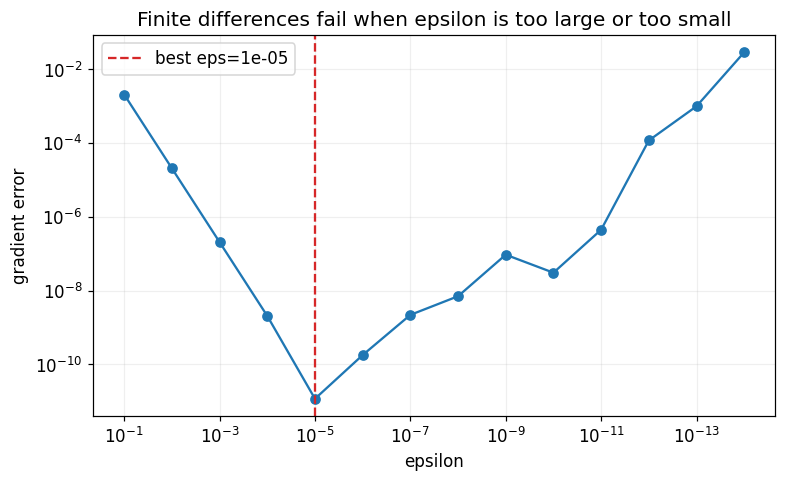

In [3]:
plt.loglog(eps_values, errors, 'o-')
plt.axvline(eps_values[best], color='tab:red', ls='--', label=f'best eps={eps_values[best]:.0e}')
plt.gca().invert_xaxis(); plt.xlabel('epsilon'); plt.ylabel('gradient error')
plt.title('Finite differences fail when epsilon is too large or too small'); plt.legend()
savefig('24_autodiff_demo')
report('autodiff', {'f_analytic': analytic.tolist(), 'f_numeric': numeric_f.tolist(),
                    'g_best_epsilon': eps_values[best], 'g_best_error': errors[best]})

## 解讀與延伸

先描述圖或表直接支持的結果，再說明這個縮編實驗不能代表完整模型的哪些面向。